# Packages

This notebook is the first external-packages notebook after `1_python3.ipynb`. It focuses on the core scientific and data ecosystem of Python before any formal modeling workflow is introduced. The goal is to understand the abstractions, tradeoffs, and common workflows of the most important pre-modeling packages: `numpy`, `pandas`, `scipy`, `matplotlib`, `seaborn`, and `pyarrow`.


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
import random
import shutil

NOTEBOOK_DIR = Path.cwd().resolve()
GENERATED_DIR = NOTEBOOK_DIR / "generated_examples"
GENERATED_DIR.mkdir(exist_ok=True)

for path in GENERATED_DIR.iterdir():
    if path.is_dir():
        shutil.rmtree(path)
    else:
        path.unlink()

random.seed(0)
print(f"Notebook setup complete. Generated files will go to {GENERATED_DIR}")


Notebook setup complete. Generated files will go to /Users/alexandershubert/git/python_course/notebooks/generated_examples


## Table of Contents

This notebook is organized as a package-first companion to the Python language notebook. Use the chapter links for broad navigation and the subsection links for focused review.

### [1. NumPy Foundations](#1-numpy-foundations)
- [1.1 Why arrays matter beyond Python lists](#11-why-arrays-matter-beyond-python-lists)
- [1.2 Creating arrays and understanding `dtype`](#12-creating-arrays-and-understanding-dtype)
- [1.3 Shape, dimensions, and broadcasting](#13-shape-dimensions-and-broadcasting)
- [1.4 Indexing, slicing, masking](#14-indexing-slicing-masking)
- [1.5 Vectorized operations](#15-vectorized-operations)
- [1.6 Aggregation and reduction patterns](#16-aggregation-and-reduction-patterns)
- [1.7 Reshaping, stacking, and concatenation](#17-reshaping-stacking-and-concatenation)
- [1.8 Random generation and reproducibility](#18-random-generation-and-reproducibility)
- [1.9 When NumPy is the right abstraction](#19-when-numpy-is-the-right-abstraction)

### [2. Pandas for Tabular Data](#2-pandas-for-tabular-data)
- [2.1 `Series` and `DataFrame` mental model](#21-series-and-dataframe-mental-model)
- [2.2 Reading and constructing tabular data](#22-reading-and-constructing-tabular-data)
- [2.3 Column selection, row filtering, boolean masks](#23-column-selection-row-filtering-boolean-masks)
- [2.4 Missing data and null semantics](#24-missing-data-and-null-semantics)
- [2.5 Type conversion and categorical thinking](#25-type-conversion-and-categorical-thinking)
- [2.6 Groupby, aggregation, and transformation](#26-groupby-aggregation-and-transformation)
- [2.7 Joining, merging, and concatenation](#27-joining-merging-and-concatenation)
- [2.8 Time series basics and datetime columns](#28-time-series-basics-and-datetime-columns)
- [2.9 Reshaping with pivot, melt, stack](#29-reshaping-with-pivot-melt-stack)
- [2.10 When pandas is the right abstraction](#210-when-pandas-is-the-right-abstraction)

### [3. SciPy as the Scientific Toolbox](#3-scipy-as-the-scientific-toolbox)
- [3.1 What SciPy adds beyond NumPy](#31-what-scipy-adds-beyond-numpy)
- [3.2 Descriptive and statistical utilities in `scipy.stats`](#32-descriptive-and-statistical-utilities-in-scipystats)
- [3.3 Distance and similarity concepts](#33-distance-and-similarity-concepts)
- [3.4 Interpolation basics](#34-interpolation-basics)
- [3.5 Optimization intuition without ML](#35-optimization-intuition-without-ml)
- [3.6 Sparse matrices at a conceptual level](#36-sparse-matrices-at-a-conceptual-level)
- [3.7 Signal and numerical routine examples](#37-signal-and-numerical-routine-examples)
- [3.8 When to reach for SciPy](#38-when-to-reach-for-scipy)

### [4. Matplotlib for Core Plotting](#4-matplotlib-for-core-plotting)
- [4.1 Figure, axes, and plotting mental model](#41-figure-axes-and-plotting-mental-model)
- [4.2 Line plots](#42-line-plots)
- [4.3 Scatter plots and categorical comparisons](#43-scatter-plots-and-categorical-comparisons)
- [4.4 Histograms and distributions](#44-histograms-and-distributions)
- [4.5 Subplots and layout composition](#45-subplots-and-layout-composition)
- [4.6 Labels, legends, titles, and annotation](#46-labels-legends-titles-and-annotation)
- [4.7 Style, readability, and publication habits](#47-style-readability-and-publication-habits)
- [4.8 Saving figures correctly](#48-saving-figures-correctly)
- [4.9 When low-level plotting control matters](#49-when-low-level-plotting-control-matters)

### [5. Seaborn for Statistical Visualization](#5-seaborn-for-statistical-visualization)
- [5.1 How seaborn relates to matplotlib](#51-how-seaborn-relates-to-matplotlib)
- [5.2 Distribution plots](#52-distribution-plots)
- [5.3 Relational plots](#53-relational-plots)
- [5.4 Categorical plots](#54-categorical-plots)
- [5.5 Heatmaps and correlation-style displays](#55-heatmaps-and-correlation-style-displays)
- [5.6 Faceting and small multiples](#56-faceting-and-small-multiples)
- [5.7 Theme setting and visual defaults](#57-theme-setting-and-visual-defaults)
- [5.8 When seaborn is preferable to raw matplotlib](#58-when-seaborn-is-preferable-to-raw-matplotlib)

### [6. PyArrow and Modern Data Interchange](#6-pyarrow-and-modern-data-interchange)
- [6.1 Why Arrow matters in the modern Python data stack](#61-why-arrow-matters-in-the-modern-python-data-stack)
- [6.2 Arrays, tables, and schema concepts](#62-arrays-tables-and-schema-concepts)
- [6.3 Converting between pandas and Arrow](#63-converting-between-pandas-and-arrow)
- [6.4 Columnar storage and memory layout intuition](#64-columnar-storage-and-memory-layout-intuition)
- [6.5 Reading and writing Parquet](#65-reading-and-writing-parquet)
- [6.6 Type fidelity and schema awareness](#66-type-fidelity-and-schema-awareness)
- [6.7 When Arrow improves workflows](#67-when-arrow-improves-workflows)

### [7. Cross-Package Workflow Patterns](#7-cross-package-workflow-patterns)
- [7.1 NumPy to pandas and back](#71-numpy-to-pandas-and-back)
- [7.2 pandas with matplotlib and seaborn](#72-pandas-with-matplotlib-and-seaborn)
- [7.3 pandas with Arrow and Parquet](#73-pandas-with-arrow-and-parquet)
- [7.4 Choosing the right package for the job](#74-choosing-the-right-package-for-the-job)
- [7.5 Common anti-patterns in early data work](#75-common-anti-patterns-in-early-data-work)

### [8. Style, Performance, and Practical Judgment](#8-style-performance-and-practical-judgment)
- [8.1 Vectorization vs Python loops](#81-vectorization-vs-python-loops)
- [8.2 Memory awareness in tabular and array code](#82-memory-awareness-in-tabular-and-array-code)
- [8.3 Readability vs clever chaining](#83-readability-vs-clever-chaining)
- [8.4 Reproducibility and deterministic examples](#84-reproducibility-and-deterministic-examples)
- [8.5 How experienced Python users think about the scientific stack](#85-how-experienced-python-users-think-about-the-scientific-stack)



# 1. NumPy Foundations

NumPy is the foundation of most scientific Python work because it gives Python an efficient array model and vectorized numerical operations. The core mental shift is to stop thinking in terms of lists of Python objects and start thinking in terms of shaped arrays with dtypes and bulk operations. For a graduate-level refresher, the important point is not just syntax, but when the array abstraction changes what is computationally natural and performant.


## 1.1 Why arrays matter beyond Python lists

Python lists are flexible containers of object references, while NumPy arrays store homogeneous data in contiguous blocks that support numerical computation efficiently. That difference affects speed, memory layout, and the kinds of operations that are natural to express. The key teaching point is that arrays are not just faster lists, but a different computational model.


In [2]:
import numpy as np

py_list = [1, 2, 3, 4]
np_array = np.array([1, 2, 3, 4])
print(type(py_list), type(np_array))
print(np_array * 2)
print([value * 2 for value in py_list])

<class 'list'> <class 'numpy.ndarray'>
[2 4 6 8]
[2, 4, 6, 8]


## 1.2 Creating arrays and understanding `dtype`

Array creation is simple on the surface, but `dtype` is one of the most important concepts in numerical Python. The dtype controls storage, interpretation, precision, and sometimes performance. A good refresher habit is to inspect dtypes early rather than assuming values behave exactly like Python scalars.


In [3]:
integers = np.array([1, 2, 3], dtype=np.int64)
floats = np.array([1, 2, 3], dtype=np.float64)
print(integers, integers.dtype)
print(floats, floats.dtype)
print(np.array([1, 2.5, 3]).dtype)

[1 2 3] int64
[1. 2. 3.] float64
float64


## 1.3 Shape, dimensions, and broadcasting

Shape tells you how data is organized across axes, and dimensions tell you how many axes an array has. Broadcasting lets NumPy align arrays of compatible shapes without explicit Python loops. This is powerful, but it only feels intuitive once you think in terms of axes rather than element-by-element iteration.


In [4]:
matrix = np.array([[1, 2, 3], [4, 5, 6]])
vector = np.array([10, 20, 30])
print(matrix.shape, matrix.ndim)
print(matrix + vector)
print((matrix + vector).shape)

(2, 3) 2
[[11 22 33]
 [14 25 36]]
(2, 3)


## 1.4 Indexing, slicing, masking

NumPy indexing extends familiar Python slicing with multidimensional selection and boolean masks. This makes it easy to isolate meaningful subsets of data without writing manual loops. The important discipline is to read each selection expression as a statement about shape as well as values.


In [5]:
data = np.array([[5, 8, 1], [7, 2, 9], [4, 6, 3]])
print(data[0, 1])
print(data[:, 1])
mask = data > 5
print(mask)
print(data[mask])

8
[8 2 6]
[[False  True False]
 [ True False  True]
 [False  True False]]
[8 7 9 6]


## 1.5 Vectorized operations

Vectorization means expressing operations over whole arrays at once instead of stepping through Python loops. That usually makes code shorter, clearer, and far faster for numeric workloads. The bigger lesson is that good NumPy style often begins by reframing the problem so that array operations become possible.


In [6]:
values = np.array([1.5, 2.0, 3.5, 4.0])
centered = values - values.mean()
scaled = centered / values.std()
print(centered)
print(np.round(scaled, 3))

[-1.25 -0.75  0.75  1.25]
[-1.213 -0.728  0.728  1.213]


## 1.6 Aggregation and reduction patterns

Aggregations collapse data along an axis to summarize it. In practice, this is how arrays become analytical tools rather than just storage containers. You should pay attention to which axis is being reduced, because that changes the semantic meaning of the result.


In [7]:
scores = np.array([[80, 92, 88], [75, 85, 91], [90, 87, 93]])
print(scores.mean())
print(scores.mean(axis=0))
print(scores.max(axis=1))

86.77777777777777
[81.66666667 88.         90.66666667]
[92 91 93]


## 1.7 Reshaping, stacking, and concatenation

Scientific code often requires the same data to be reorganized into a different shape. Reshaping changes the structural view of data, while stacking and concatenation combine multiple arrays into one larger arrangement. The main habit to refresh is checking that dimensions line up before assuming the operation is meaningful.


In [8]:
base = np.arange(12)
reshaped = base.reshape(3, 4)
extra = np.array([[100, 101, 102, 103]])
print(reshaped)
print(np.vstack([reshaped, extra]))
print(np.hstack([reshaped, np.full((3, 1), -1)]))

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[  0   1   2   3]
 [  4   5   6   7]
 [  8   9  10  11]
 [100 101 102 103]]
[[ 0  1  2  3 -1]
 [ 4  5  6  7 -1]
 [ 8  9 10 11 -1]]


## 1.8 Random generation and reproducibility

Random generation is essential in simulation, sampling, and synthetic examples, but reproducibility matters just as much as randomness itself. Modern NumPy encourages the `Generator` API instead of older global random functions. A serious workflow treats seeds as part of the computational specification.


In [9]:
rng = np.random.default_rng(42)
sample = rng.normal(loc=0.0, scale=1.0, size=5)
integers = rng.integers(low=0, high=10, size=5)
print(np.round(sample, 3))
print(integers)

[ 0.305 -1.04   0.75   0.941 -1.951]
[5 9 7 7 7]


## 1.9 When NumPy is the right abstraction

NumPy is excellent when data is numeric, regular, and amenable to bulk operations. It is less compelling when data is deeply heterogeneous, string-heavy, or dominated by high-level business logic. Good judgment means choosing NumPy because the problem is array-shaped, not just because the library is available.


In [10]:
decision_table = {
    'dense numeric matrix': 'NumPy is a strong fit',
    'ragged nested records': 'plain Python or pandas may fit better',
    'vectorized simulation': 'NumPy is a strong fit',
}
print(decision_table)

{'dense numeric matrix': 'NumPy is a strong fit', 'ragged nested records': 'plain Python or pandas may fit better', 'vectorized simulation': 'NumPy is a strong fit'}


### Common Mistake / Nuance

A common mistake is to write Python loops around arrays and then assume NumPy is being used effectively. Another is to ignore shape and dtype until a bug appears downstream. The real gain from NumPy comes from adopting array-first thinking, not from importing the package and continuing to program as if everything were a list.


### Practice Prompts

- Rewrite a loop-based numerical calculation using vectorized array operations.
- Show one example where broadcasting makes code clearer and one where it makes code harder to read.
- Explain how dtype choice can change both memory use and numerical behavior.


### Chapter Recap

NumPy is the foundational array library of the scientific Python stack. Its central ideas are dtype, shape, axis-aware computation, and vectorization. Once those become intuitive, many higher-level libraries become easier to understand because they build on the same numerical model.


# 2. Pandas for Tabular Data

Pandas is the dominant tabular data library in Python because it combines labeled axes, rich indexing, and dataframe operations in one tool. Its real strength is not that it stores tables, but that it lets you express common data-cleaning and summarization tasks compactly. The most important refresher point is to reason about columns, indices, and missing values explicitly rather than treating a dataframe like a generic spreadsheet.


## 2.1 `Series` and `DataFrame` mental model

A `Series` is a labeled one-dimensional array, while a `DataFrame` is a labeled table of aligned series. Labels are part of the semantics, not just decoration. That means column names and index values affect how operations align and combine data.


In [11]:
import pandas as pd

series = pd.Series([91, 84, 95], index=['Alice', 'Bob', 'Cara'])
frame = pd.DataFrame({'name': ['Alice', 'Bob'], 'score': [91, 84]})
print(series)
print(frame)
print(frame.columns.tolist())

Alice    91
Bob      84
Cara     95
dtype: int64
    name  score
0  Alice     91
1    Bob     84
['name', 'score']


## 2.2 Reading and constructing tabular data

Pandas can construct tables from Python objects or read them from common storage formats. The learning goal is to move fluidly between raw records and structured tabular form. Construction choices matter because they influence column types and downstream operations.


In [12]:
records = [
    {'name': 'Alice', 'score': 91, 'track': 'python'},
    {'name': 'Bob', 'score': 84, 'track': 'ml'},
]
df = pd.DataFrame(records)
csv_path = GENERATED_DIR / 'packages_scores.csv'
df.to_csv(csv_path, index=False)
print(df)
print(pd.read_csv(csv_path))

    name  score   track
0  Alice     91  python
1    Bob     84      ml
    name  score   track
0  Alice     91  python
1    Bob     84      ml


## 2.3 Column selection, row filtering, boolean masks

Selection and filtering are the day-to-day mechanics of dataframe work. Pandas combines label-based access with boolean masking, which makes expressive row selection possible. The important habit is to write filters that read like data conditions rather than like opaque indexing tricks.


In [13]:
df = pd.DataFrame({'name': ['Alice', 'Bob', 'Cara'], 'score': [91, 84, 95], 'track': ['python', 'ml', 'python']})
print(df[['name', 'score']])
mask = (df['score'] >= 90) & (df['track'] == 'python')
print(df.loc[mask])

    name  score
0  Alice     91
1    Bob     84
2   Cara     95
    name  score   track
0  Alice     91  python
2   Cara     95  python


## 2.4 Missing data and null semantics

Missing data is central to pandas, and null semantics deserve explicit attention. `NaN`, `pd.NA`, and null-aware operations can change how comparisons and aggregations behave. A mature pandas workflow checks missingness early instead of discovering it accidentally during analysis.


In [14]:
df = pd.DataFrame({'name': ['Alice', 'Bob', 'Cara'], 'score': [91, None, 95], 'city': ['London', 'Paris', None]})
print(df.isna())
print(df['score'].mean())
print(df.fillna({'score': 0, 'city': 'unknown'}))

    name  score   city
0  False  False  False
1  False   True  False
2  False  False   True
93.0
    name  score     city
0  Alice   91.0   London
1    Bob    0.0    Paris
2   Cara   95.0  unknown


## 2.5 Type conversion and categorical thinking

Dataframes are easier to reason about when columns have meaningful types. Conversion is not only about fixing import issues, but also about making semantics explicit for dates, categories, and numerics. Categorical types matter because repeated labels often behave more like levels than free-form strings.


In [15]:
df = pd.DataFrame({'department': ['eng', 'eng', 'sales'], 'joined': ['2024-01-01', '2024-02-15', '2024-03-01']})
df['department'] = df['department'].astype('category')
df['joined'] = pd.to_datetime(df['joined'])
print(df.dtypes)
print(df['department'].cat.categories.tolist())

department          category
joined        datetime64[ns]
dtype: object
['eng', 'sales']


## 2.6 Groupby, aggregation, and transformation

Groupby is one of pandas’ defining features because it turns tabular records into grouped summaries and transformations. It is best understood as split, apply, and combine. The key teaching point is to distinguish between aggregation, which reduces groups, and transformation, which preserves row count.


In [16]:
df = pd.DataFrame({'team': ['A', 'A', 'B', 'B'], 'score': [10, 14, 9, 11]})
print(df.groupby('team')['score'].mean())
df['team_centered'] = df['score'] - df.groupby('team')['score'].transform('mean')
print(df)

team
A    12.0
B    10.0
Name: score, dtype: float64
  team  score  team_centered
0    A     10           -2.0
1    A     14            2.0
2    B      9           -1.0
3    B     11            1.0


## 2.7 Joining, merging, and concatenation

Real tabular work often involves combining related tables. Pandas supports row-wise concatenation and key-based merges, but these serve different purposes. The main judgment skill is knowing whether you are appending similar records or enriching records with related attributes.


In [17]:
students = pd.DataFrame({'student_id': [1, 2, 3], 'name': ['Alice', 'Bob', 'Cara']})
scores = pd.DataFrame({'student_id': [1, 2, 3], 'score': [91, 84, 95]})
merged = students.merge(scores, on='student_id')
print(merged)
print(pd.concat([merged, merged.assign(student_id=[4, 5, 6])], ignore_index=True).head())

   student_id   name  score
0           1  Alice     91
1           2    Bob     84
2           3   Cara     95
   student_id   name  score
0           1  Alice     91
1           2    Bob     84
2           3   Cara     95
3           4  Alice     91
4           5    Bob     84


## 2.8 Time series basics and datetime columns

Pandas has strong datetime support because many practical datasets are time-oriented. Converting to datetime unlocks filtering, extraction, resampling, and calendar-aware logic. The key refresher point is that strings that look like dates are not yet time-aware data.


In [18]:
df = pd.DataFrame({'date': pd.to_datetime(['2025-01-01', '2025-01-03', '2025-01-05']), 'value': [10, 12, 15]})
df['weekday'] = df['date'].dt.day_name()
print(df)
print(df.set_index('date').resample('D').ffill())

        date  value    weekday
0 2025-01-01     10  Wednesday
1 2025-01-03     12     Friday
2 2025-01-05     15     Sunday
            value    weekday
date                        
2025-01-01     10  Wednesday
2025-01-02     10  Wednesday
2025-01-03     12     Friday
2025-01-04     12     Friday
2025-01-05     15     Sunday


## 2.9 Reshaping with pivot, melt, stack

Wide and long formats are alternative views of the same information, and pandas provides tools to move between them. Reshaping matters because plotting, aggregation, and interchange often prefer different table structures. The important habit is to ask which shape makes the next operation simplest.


In [19]:
wide = pd.DataFrame({'name': ['Alice', 'Bob'], 'math': [90, 85], 'physics': [88, 92]})
long = wide.melt(id_vars='name', var_name='subject', value_name='score')
print(long)
print(long.pivot(index='name', columns='subject', values='score'))

    name  subject  score
0  Alice     math     90
1    Bob     math     85
2  Alice  physics     88
3    Bob  physics     92
subject  math  physics
name                  
Alice      90       88
Bob        85       92


## 2.10 When pandas is the right abstraction

Pandas is ideal when data is table-shaped, column-oriented, and rich in labels. It is less ideal for very large distributed workloads, extremely strict schema systems, or raw numerical kernels where NumPy is simpler. Good practice means choosing pandas because the data problem is relational and tabular, not because every dataset looks like a dataframe by default.


In [20]:
use_cases = pd.Series({
    'small labeled table': 'pandas',
    'dense numeric tensor': 'numpy',
    'columnar file interchange': 'pyarrow',
})
print(use_cases)

small labeled table           pandas
dense numeric tensor           numpy
columnar file interchange    pyarrow
dtype: object


### Common Mistake / Nuance

A common mistake is to chain many operations without checking intermediate shape, dtype, or missingness. Another is to use pandas for workloads that are really array-centric or schema-centric. Pandas is strongest when its labeling and table semantics are doing real conceptual work for you.


### Practice Prompts

- Take a small CSV-like dataset and show selection, filtering, grouping, and reshaping in sequence.
- Explain the difference between `groupby().agg()` and `groupby().transform()` with a concrete example.
- Show one case where converting a string column to datetime changes what operations become natural.


### Chapter Recap

Pandas is the central dataframe library of Python. Its power comes from labeled columns, table-aware operations, missing-data handling, and groupby/merge/reshape workflows. Strong pandas usage is less about memorizing methods and more about understanding tabular semantics clearly.


# 3. SciPy as the Scientific Toolbox

SciPy extends NumPy with higher-level scientific routines that would be cumbersome to recreate manually. It is less a single abstraction than a toolbox of carefully engineered subpackages for statistics, optimization, interpolation, sparse structures, and more. The educational goal here is to see what kinds of scientific tasks naturally migrate from raw array operations into dedicated scientific routines.


## 3.1 What SciPy adds beyond NumPy

NumPy gives you array primitives and many numerical operations, but SciPy adds domain-focused routines built on top of that base. In practice, SciPy matters when the task is not just arithmetic on arrays but a recognized scientific computation pattern. The right mental model is that SciPy sits one level above raw numerical storage and computation.


In [21]:
from scipy import interpolate, optimize, signal, sparse, stats
from scipy.spatial import distance

scipy_map = {
    'numpy': 'array storage and vectorized numerical operations',
    'scipy': 'specialized scientific routines built on arrays',
}
print(scipy_map)

{'numpy': 'array storage and vectorized numerical operations', 'scipy': 'specialized scientific routines built on arrays'}


## 3.2 Descriptive and statistical utilities in `scipy.stats`

The `scipy.stats` module provides descriptive statistics, distributions, and statistical tests in a consistent interface. This matters because many analytical tasks need more than means and standard deviations. Even before modeling, it is useful to understand how the scientific stack represents distributional questions.


In [22]:
scores = np.array([80, 84, 88, 90, 91, 95])
print(stats.describe(scores))
print(stats.zscore(scores))

DescribeResult(nobs=6, minmax=(np.int64(80), np.int64(95)), mean=np.float64(88.0), variance=np.float64(28.400000000000002), skewness=np.float64(-0.28662119270250264), kurtosis=np.float64(-0.9617139456457053))
[-1.6444529  -0.82222645  0.          0.41111323  0.61666984  1.43889629]


## 3.3 Distance and similarity concepts

Distance functions are important in clustering, similarity analysis, and geometry-adjacent tasks, even before formal modeling begins. SciPy provides reliable implementations rather than forcing you to hand-code these routines repeatedly. The deeper point is to think about what notion of closeness a computation really needs.


In [23]:
a = np.array([1.0, 2.0, 3.0])
b = np.array([2.0, 4.0, 6.0])
print(distance.euclidean(a, b))
print(distance.cosine(a, b))

3.741657386773941
0.0


## 3.4 Interpolation basics

Interpolation estimates values between known observations. This is common in scientific and engineering workflows where measurements are discrete but interpretation requires continuity. The important idea is that interpolation is a modeling assumption about smoothness, not just a coding trick.


In [24]:
x = np.array([0, 1, 2, 3])
y = np.array([0, 1, 4, 9])
interp = interpolate.interp1d(x, y, kind='linear')
print(interp([0.5, 1.5, 2.5]))

[0.5 2.5 6.5]


## 3.5 Optimization intuition without ML

Optimization is broader than machine learning and appears whenever you want to minimize cost, error, or energy. SciPy’s optimization routines provide a way to express such problems cleanly. The key refresher lesson is to separate the objective function from the solver that searches it.


In [25]:
objective = lambda x: (x - 3) ** 2 + 2
result = optimize.minimize_scalar(objective)
print(round(result.x, 3), round(result.fun, 3))

3.0 2.0


## 3.6 Sparse matrices at a conceptual level

Sparse matrices are useful when most entries are zero and dense storage would waste memory and computation. SciPy exposes sparse formats that make such structures practical in Python. Even if you do not use them daily, it is important to recognize when a problem is sparse by nature.


In [26]:
dense = np.array([[0, 1, 0], [0, 0, 0], [2, 0, 3]])
sparse_matrix = sparse.csr_matrix(dense)
print(sparse_matrix)
print(sparse_matrix.toarray())

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3 stored elements and shape (3, 3)>
  Coords	Values
  (0, 1)	1
  (2, 0)	2
  (2, 2)	3
[[0 1 0]
 [0 0 0]
 [2 0 3]]


## 3.7 Signal and numerical routine examples

SciPy contains many specialized numerical helpers, including signal processing tools. These examples matter because they show the breadth of the library beyond statistics alone. The teaching value is to build the reflex that scientific routines often already exist in a tested library form.


In [27]:
signal_values = np.array([1, 3, 2, 5, 4, 6, 5])
smoothed = signal.savgol_filter(signal_values, window_length=5, polyorder=2)
print(signal_values)
print(np.round(smoothed, 3))

[1 3 2 5 4 6 5]
[1.114 2.343 3.286 3.714 5.114 5.457 5.086]


## 3.8 When to reach for SciPy

SciPy is appropriate when the computation has a recognizable scientific form and correctness matters more than hand-rolled convenience. It is usually a poor fit if the task is just ordinary table manipulation or straightforward plotting. Good judgment means reaching for SciPy when you want a standard numerical method, not merely when you want to sound scientific.


In [28]:
cases = {
    'distance between vectors': 'scipy.spatial.distance',
    'grouped tabular summary': 'pandas',
    'linear interpolation': 'scipy.interpolate',
}
print(cases)

{'distance between vectors': 'scipy.spatial.distance', 'grouped tabular summary': 'pandas', 'linear interpolation': 'scipy.interpolate'}


### Common Mistake / Nuance

A common mistake is to think of SciPy as a monolithic advanced package that only matters for specialists. In reality, it is a practical toolbox that becomes useful whenever a numerical task maps onto a standard method. The main risk is using a routine mechanically without understanding the assumptions it encodes.


### Practice Prompts

- Compare a NumPy-only calculation with a SciPy routine that solves a more structured scientific problem.
- Explain what interpolation assumes and when that assumption may be misleading.
- Show one sparse data situation where a dense array is conceptually the wrong storage choice.


### Chapter Recap

SciPy extends numerical Python into a scientific toolbox. Its value lies in statistics, distances, interpolation, optimization, and specialized numerical routines. The essential judgment is to recognize when a problem deserves a standard scientific method instead of a custom workaround.


# 4. Matplotlib for Core Plotting

Matplotlib is the foundational plotting library in Python and remains important because many higher-level tools build on its figure-and-axes model. It can feel low-level at first, but that explicitness is also what makes it flexible. The main teaching goal is to understand the figure, axes, and annotation model well enough that plotting decisions become deliberate rather than trial-and-error.


## 4.1 Figure, axes, and plotting mental model

Matplotlib separates the overall figure from the axes that hold plotted data. That distinction matters because complex visualizations often involve several axes inside one figure. Once the object model is clear, plotting code becomes easier to compose and customize.


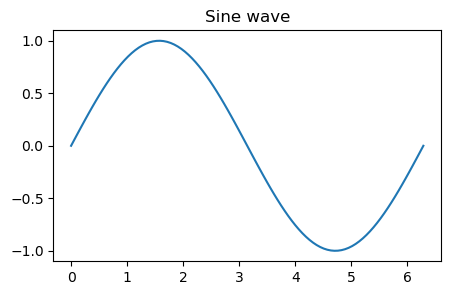

In [29]:
import matplotlib.pyplot as plt

x = np.linspace(0, 2 * np.pi, 100)
y = np.sin(x)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, y)
ax.set_title('Sine wave')
plt.show()
plt.close(fig)

## 4.2 Line plots

Line plots are best when the x-axis has meaningful order such as time, sequence, or a continuous variable. Their main purpose is to show trend, continuity, and relative movement. The key skill is to label them well enough that the story is readable without narration.


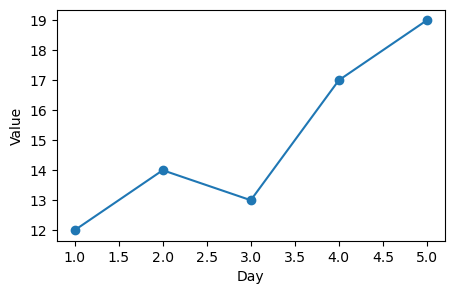

In [30]:
days = np.arange(1, 6)
values = np.array([12, 14, 13, 17, 19])
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(days, values, marker='o')
ax.set_xlabel('Day')
ax.set_ylabel('Value')
plt.show()
plt.close(fig)

## 4.3 Scatter plots and categorical comparisons

Scatter plots show relationships between paired numeric variables and can also encode categories by color or marker style. They are useful for seeing spread, grouping, and rough association. The important habit is to avoid overloading the plot with encodings that make interpretation harder than the underlying data.


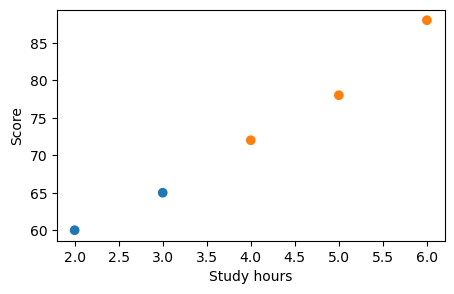

In [31]:
points = pd.DataFrame({'study_hours': [2, 3, 4, 5, 6], 'score': [60, 65, 72, 78, 88], 'track': ['A', 'A', 'B', 'B', 'B']})
colors = points['track'].map({'A': 'tab:blue', 'B': 'tab:orange'})
fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(points['study_hours'], points['score'], c=colors)
ax.set_xlabel('Study hours')
ax.set_ylabel('Score')
plt.show()
plt.close(fig)

## 4.4 Histograms and distributions

Histograms summarize a distribution by grouping values into bins. They are often the first sensible plot when you want to understand spread, skew, and concentration. The main design choice is that binning itself influences what patterns become visible.


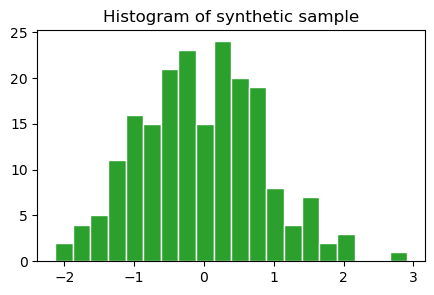

In [32]:
sample = np.random.default_rng(42).normal(loc=0, scale=1, size=200)
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(sample, bins=20, color='tab:green', edgecolor='white')
ax.set_title('Histogram of synthetic sample')
plt.show()
plt.close(fig)

## 4.5 Subplots and layout composition

Subplots let one figure compare several related views at once. This matters because many analytical questions are comparative rather than single-view. The teaching goal is to think of a figure as a designed layout rather than one default chart.


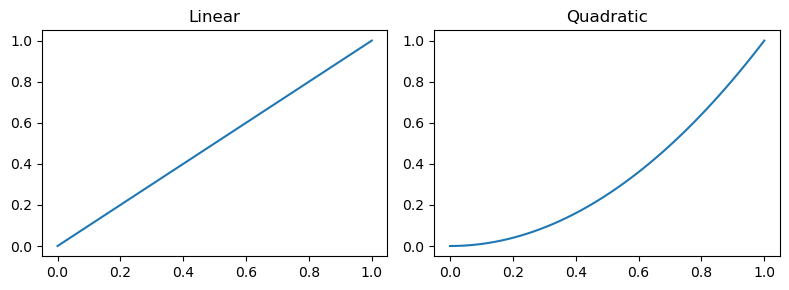

In [33]:
x = np.linspace(0, 1, 50)
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].plot(x, x)
axes[0].set_title('Linear')
axes[1].plot(x, x**2)
axes[1].set_title('Quadratic')
fig.tight_layout()
plt.show()
plt.close(fig)

## 4.6 Labels, legends, titles, and annotation

Annotation is what turns a plot from a technical artifact into a communicative one. Titles, axis labels, and legends should answer the reader’s first questions without clutter. The key discipline is to annotate for interpretation, not just decoration.


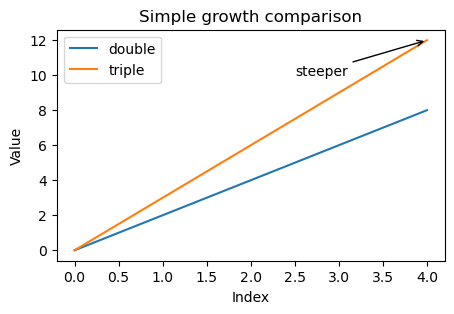

In [34]:
x = np.arange(5)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, x * 2, label='double')
ax.plot(x, x * 3, label='triple')
ax.set_title('Simple growth comparison')
ax.set_xlabel('Index')
ax.set_ylabel('Value')
ax.legend()
ax.annotate('steeper', xy=(4, 12), xytext=(2.5, 10), arrowprops={'arrowstyle': '->'})
plt.show()
plt.close(fig)

## 4.7 Style, readability, and publication habits

Matplotlib can produce both elegant and unreadable charts depending on styling choices. Readability depends on color contrast, scale choices, tick density, and figure sizing more than on ornament. A professional habit is to treat the plot as an argument for clarity, not a canvas for unnecessary effects.


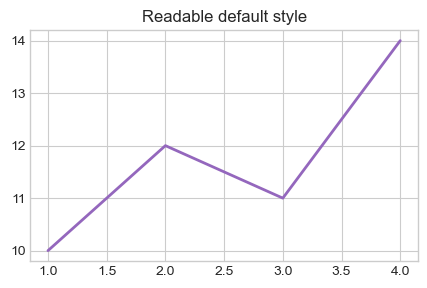

In [35]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot([1, 2, 3, 4], [10, 12, 11, 14], color='tab:purple', linewidth=2)
ax.set_title('Readable default style')
plt.show()
plt.close(fig)
plt.style.use('default')

## 4.8 Saving figures correctly

Saving a figure is part of the analytical workflow, not an afterthought. Choices like file format, bounding box, and resolution affect whether the figure travels well into reports and presentations. The key point is to save explicitly and reproducibly rather than relying on screenshots.


In [36]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot([0, 1, 2], [2, 3, 5])
ax.set_title('Saved figure example')
figure_path = GENERATED_DIR / 'matplotlib_line.png'
fig.savefig(figure_path, dpi=120, bbox_inches='tight')
print(figure_path, figure_path.exists())
plt.close(fig)

/Users/alexandershubert/git/python_course/notebooks/generated_examples/matplotlib_line.png True


## 4.9 When low-level plotting control matters

Matplotlib’s lower-level API becomes valuable when default plotting wrappers are too rigid. This often happens when you need fine layout control, custom annotations, or multi-axis figure composition. The teaching lesson is that low-level control is useful when it serves communication, not when it merely increases code volume.


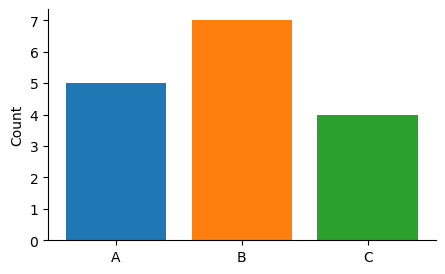

In [37]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['A', 'B', 'C'], [5, 7, 4], color=['tab:blue', 'tab:orange', 'tab:green'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Count')
plt.show()
plt.close(fig)

### Common Mistake / Nuance

A common mistake is to treat plotting as the last decorative step instead of as part of the reasoning process. Another is to accept default labels and scaling even when they obscure the point of the chart. Good plotting is analytical communication, not just data display.


### Practice Prompts

- Create two versions of the same plot and explain which communicates better and why.
- Show a case where subplots clarify comparison better than overlaying everything on one axes.
- Save one figure to `generated_examples` and explain your format and resolution choices.


### Chapter Recap

Matplotlib is the core plotting engine of the scientific Python stack. Its essential concepts are figures, axes, visual encodings, and explicit annotation. Once those are stable, higher-level plotting libraries become easier to use critically rather than passively.


# 5. Seaborn for Statistical Visualization

Seaborn builds on matplotlib to make statistical visualizations more concise and aesthetically consistent. It is especially useful when the data already lives in a pandas dataframe and the plot should reflect variable roles directly. The main refresher goal is to understand what seaborn automates and where matplotlib-level control still matters.


## 5.1 How seaborn relates to matplotlib

Seaborn is not a replacement plotting backend so much as a higher-level interface layered on top of matplotlib. It simplifies common statistical plot patterns and adopts dataframe-friendly semantics. Understanding that relationship helps you combine seaborn convenience with matplotlib customization when needed.


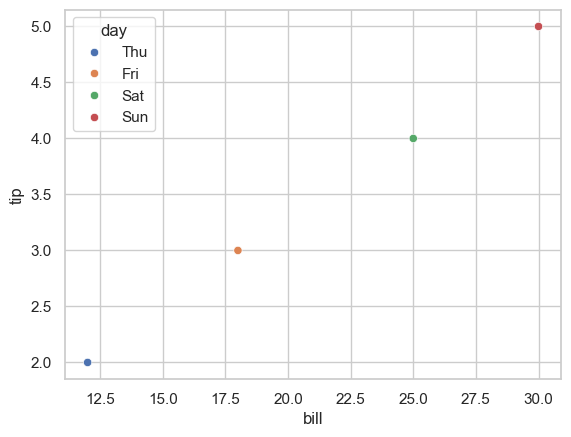

In [38]:
import seaborn as sns

tips = pd.DataFrame({'bill': [12, 18, 25, 30], 'tip': [2, 3, 4, 5], 'day': ['Thu', 'Fri', 'Sat', 'Sun']})
sns.set_theme(style='whitegrid')
ax = sns.scatterplot(data=tips, x='bill', y='tip', hue='day')
plt.show()
plt.close(ax.figure)

## 5.2 Distribution plots

Seaborn provides distribution-oriented charts that are quicker to write than raw matplotlib equivalents. This matters because exploratory data work often begins with the shape of a distribution rather than with relationships between variables. The important discipline is still to choose the view that best answers the question rather than accepting whichever plot is easiest to call.


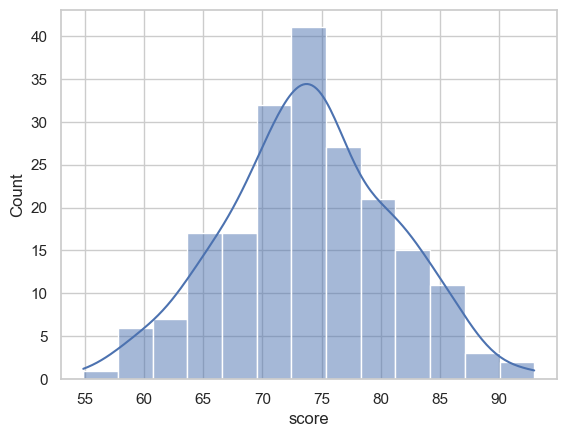

In [39]:
values = pd.DataFrame({'score': np.random.default_rng(7).normal(75, 8, 200)})
ax = sns.histplot(data=values, x='score', kde=True)
plt.show()
plt.close(ax.figure)

## 5.3 Relational plots

Relational plots show how numeric variables move together and can add categorical structure through color, size, or style. Seaborn makes these mappings concise and readable. The key lesson is that convenience should support better interpretation, not encourage overloaded charts.


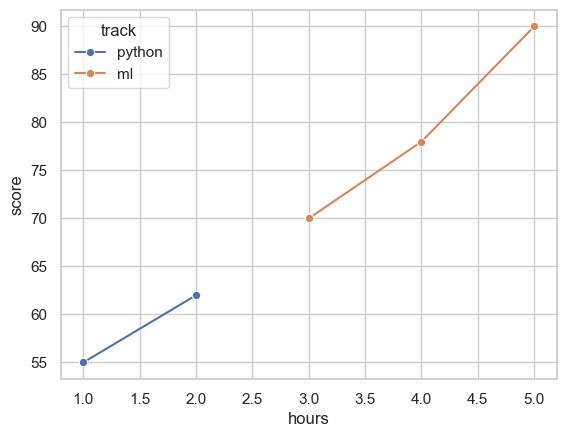

In [40]:
df = pd.DataFrame({'hours': [1, 2, 3, 4, 5], 'score': [55, 62, 70, 78, 90], 'track': ['python', 'python', 'ml', 'ml', 'ml']})
ax = sns.lineplot(data=df, x='hours', y='score', hue='track', marker='o')
plt.show()
plt.close(ax.figure)

## 5.4 Categorical plots

Categorical plots summarize distributions or central tendencies across groups. They are useful whenever the comparison is between levels rather than along a continuous axis. The teaching point is to match the plot type to whether you want raw values, summary statistics, or distributional shape.


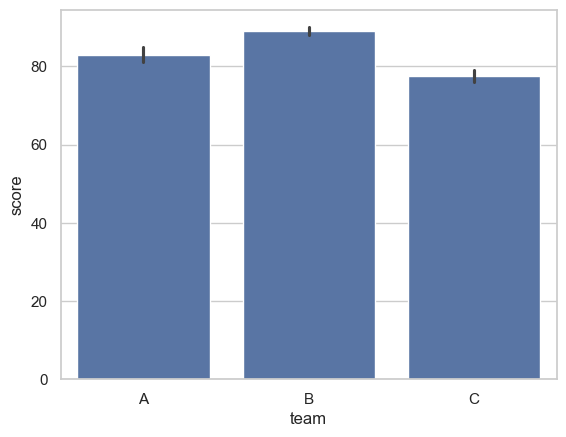

In [41]:
df = pd.DataFrame({'team': ['A', 'A', 'B', 'B', 'C', 'C'], 'score': [81, 85, 88, 90, 76, 79]})
ax = sns.barplot(data=df, x='team', y='score', estimator=np.mean)
plt.show()
plt.close(ax.figure)

## 5.5 Heatmaps and correlation-style displays

Heatmaps are effective when the main structure lives in a matrix of pairwise values or aggregated cells. Seaborn makes correlation-style displays especially straightforward. The important habit is to remember that color is a quantitative encoding and should be interpreted with scale awareness.


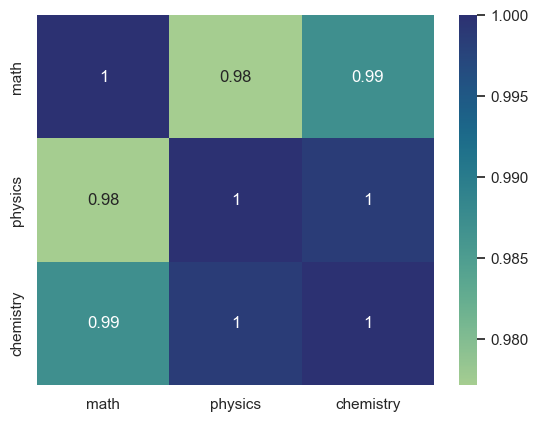

In [42]:
df = pd.DataFrame({'math': [80, 85, 90, 88], 'physics': [78, 82, 91, 87], 'chemistry': [75, 80, 89, 85]})
ax = sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='crest')
plt.show()
plt.close(ax.figure)

## 5.6 Faceting and small multiples

Faceting creates several coordinated plots split by category, which is often clearer than overplotting everything on one axes. This is one of seaborn’s most useful high-level ideas for exploratory analysis. The lesson is that repeating a simple view across groups can be more informative than compressing all groups into one busy image.


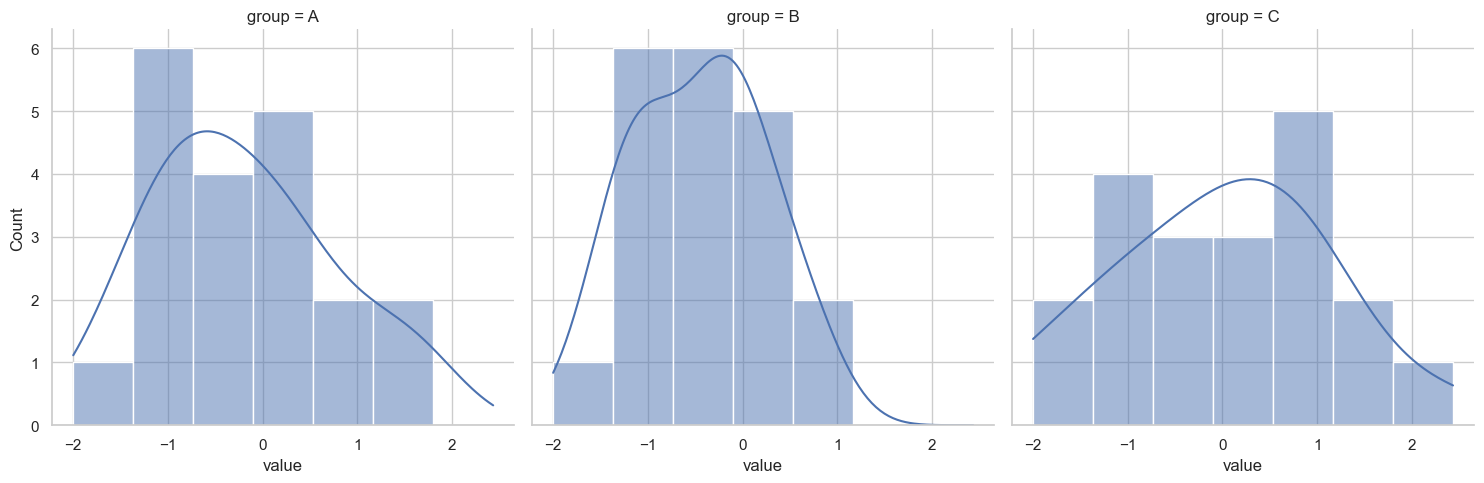

In [43]:
df = pd.DataFrame({
    'value': np.random.default_rng(5).normal(size=60),
    'group': ['A'] * 20 + ['B'] * 20 + ['C'] * 20,
})
g = sns.displot(data=df, x='value', col='group', col_wrap=3, kde=True)
plt.show()
plt.close('all')

## 5.7 Theme setting and visual defaults

Seaborn’s themes help establish visual consistency quickly. That matters because exploratory notebooks often drift into inconsistent styling if each plot uses ad hoc defaults. A disciplined theme choice makes a notebook feel intentional and easier to read.


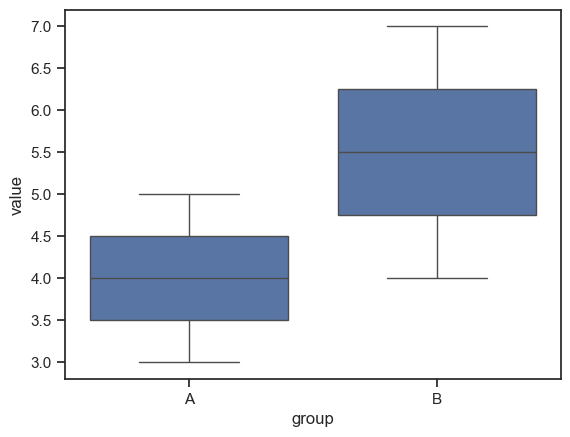

In [44]:
sns.set_theme(style='ticks', palette='deep')
ax = sns.boxplot(data=pd.DataFrame({'group': ['A', 'A', 'B', 'B'], 'value': [3, 5, 4, 7]}), x='group', y='value')
plt.show()
plt.close(ax.figure)
sns.set_theme(style='whitegrid')

## 5.8 When seaborn is preferable to raw matplotlib

Seaborn is preferable when the task is a standard statistical visualization over dataframe columns and you want concise, opinionated defaults. Raw matplotlib becomes more attractive when you need fine control over layout or unusual plot structure. The broader lesson is to choose the level of abstraction that matches the communication task, not to be loyal to one library for everything.


In [45]:
comparison = {
    'quick dataframe-based statistical chart': 'seaborn',
    'complex custom figure layout': 'matplotlib',
    'publication-specific annotation details': 'matplotlib or a combination',
}
print(comparison)

{'quick dataframe-based statistical chart': 'seaborn', 'complex custom figure layout': 'matplotlib', 'publication-specific annotation details': 'matplotlib or a combination'}


### Common Mistake / Nuance

A common mistake is to think seaborn removes the need to understand plotting decisions. In reality, it compresses syntax, but it does not eliminate the need to choose encodings, scales, and comparisons carefully. Good seaborn use still depends on analytical judgment and visual restraint.


### Practice Prompts

- Create one seaborn plot that is clearly better than its raw matplotlib counterpart for a dataframe-shaped task.
- Show a faceted view and explain why it is clearer than a single overplotted figure.
- Compare when a seaborn default helps and when it gets in the way.


### Chapter Recap

Seaborn provides high-level statistical visualization on top of matplotlib. Its strengths are dataframe integration, concise syntax, and strong defaults for exploratory analysis. The real skill is to use that convenience while still thinking critically about what the chart is claiming.


# 6. PyArrow and Modern Data Interchange

PyArrow matters because modern data workflows increasingly depend on efficient columnar memory formats and interoperable schemas. It complements pandas rather than replacing it, especially for file interchange and typed table representations. The most important refresher point is that Arrow is about columnar structure, schema fidelity, and interchange efficiency, not just another dataframe library.


## 6.1 Why Arrow matters in the modern Python data stack

Arrow provides a standardized columnar in-memory representation that many systems can share. This reduces friction when data moves across libraries, file formats, and execution engines. The key conceptual point is that memory layout and type fidelity are part of workflow design, not hidden implementation details.


In [46]:
import pyarrow as pa
import pyarrow.parquet as pq

arrow_summary = {
    'columnar memory': 'efficient for analytics and interchange',
    'schema awareness': 'types are explicit and portable',
    'parquet integration': 'common storage workflow',
}
print(arrow_summary)

{'columnar memory': 'efficient for analytics and interchange', 'schema awareness': 'types are explicit and portable', 'parquet integration': 'common storage workflow'}


## 6.2 Arrays, tables, and schema concepts

PyArrow organizes data around arrays, chunked arrays, and tables with explicit schema. This is a different emphasis from pandas’ dataframe-first mental model. Understanding schema early helps explain why Arrow is valuable in typed data pipelines.


In [47]:
arrow_table = pa.table({'name': ['Alice', 'Bob'], 'score': [91, 84]})
print(arrow_table)
print(arrow_table.schema)

pyarrow.Table
name: string
score: int64
----
name: [["Alice","Bob"]]
score: [[91,84]]
name: string
score: int64


## 6.3 Converting between pandas and Arrow

Pandas and Arrow interoperate well, but their internal assumptions are not identical. Conversion matters because many workflows want pandas ergonomics with Arrow-backed interchange. The main lesson is to understand conversion as a bridge between abstractions, not as a trivial copy-paste operation.


In [48]:
df = pd.DataFrame({'name': ['Alice', 'Bob'], 'score': [91, 84]})
arrow_table = pa.Table.from_pandas(df)
roundtrip = arrow_table.to_pandas()
print(arrow_table)
print(roundtrip)

pyarrow.Table
name: string
score: int64
----
name: [["Alice","Bob"]]
score: [[91,84]]
    name  score
0  Alice     91
1    Bob     84


## 6.4 Columnar storage and memory layout intuition

Columnar storage groups values by column rather than by row. That makes many analytical scans more efficient because the system can operate on one typed column at a time. The educational goal is not hardware detail, but the intuition that layout influences performance and interoperability.


In [49]:
table = pa.table({'a': [1, 2, 3], 'b': [10.0, 11.5, 13.0]})
print(table.column_names)
print(table['a'])
print(table.nbytes)

['a', 'b']
[
  [
    1,
    2,
    3
  ]
]
48


## 6.5 Reading and writing Parquet

Parquet is one of Arrow’s most practical companions because it stores columnar data efficiently on disk. It is common in analytics pipelines precisely because it preserves structure better than ad hoc text storage. The key workflow habit is to write and read such files explicitly from managed output paths.


In [50]:
parquet_df = pd.DataFrame({'city': ['London', 'Paris', 'Berlin'], 'visits': [10, 12, 9]})
parquet_path = GENERATED_DIR / 'cities.parquet'
parquet_table = pa.Table.from_pandas(parquet_df)
pq.write_table(parquet_table, parquet_path)
loaded = pq.read_table(parquet_path).to_pandas()
print(parquet_path.exists())
print(loaded)

True
     city  visits
0  London      10
1   Paris      12
2  Berlin       9


## 6.6 Type fidelity and schema awareness

Arrow encourages explicit thinking about types and schemas because downstream systems often depend on them. This is especially important when data moves across boundaries such as storage, serialization, or mixed-language tools. Good Arrow practice means treating schema as part of the data contract.


In [51]:
schema = pa.schema([('id', pa.int64()), ('amount', pa.float64()), ('label', pa.string())])
custom_table = pa.Table.from_pydict({'id': [1, 2], 'amount': [10.5, 11.0], 'label': ['x', 'y']}, schema=schema)
print(custom_table.schema)
print(custom_table)

id: int64
amount: double
label: string
pyarrow.Table
id: int64
amount: double
label: string
----
id: [[1,2]]
amount: [[10.5,11]]
label: [["x","y"]]


## 6.7 When Arrow improves workflows

Arrow improves workflows when typed columnar interchange matters more than interactive dataframe ergonomics alone. It is especially useful for Parquet, schema fidelity, and moving data across system boundaries. The central judgment is to use Arrow where the pipeline benefits from explicit columnar structure, not merely because it is modern.


In [52]:
workflow_choices = {
    'interactive cleaning in a notebook': 'pandas',
    'typed parquet interchange': 'pyarrow',
    'raw numeric simulation': 'numpy',
}
print(workflow_choices)

{'interactive cleaning in a notebook': 'pandas', 'typed parquet interchange': 'pyarrow', 'raw numeric simulation': 'numpy'}


### Common Mistake / Nuance

A common mistake is to assume Arrow is just a faster dataframe. It is better understood as a typed columnar interchange layer that complements other libraries. The real benefit appears when data moves across tools, files, and execution contexts.


### Practice Prompts

- Write a small pandas dataframe to Parquet and explain what Arrow contributes to that workflow.
- Create an Arrow schema explicitly and explain why schema fidelity can matter downstream.
- Compare a CSV-oriented storage habit with a Parquet-oriented storage habit for analytical data.


### Chapter Recap

PyArrow introduces a columnar, schema-aware view of data workflows. Its practical strengths are table representation, pandas interoperability, and Parquet-based interchange. The main conceptual gain is learning to think about typed data movement as part of analysis design.


# 7. Cross-Package Workflow Patterns

Real work rarely stays inside one package, so fluency depends on knowing how these tools connect. The scientific Python stack is strongest when each library is used for the part of the workflow it handles naturally. This chapter focuses on transitions and boundaries, because many inefficiencies come from using the wrong abstraction for the current step.


## 7.1 NumPy to pandas and back

NumPy and pandas interoperate well, but they do not emphasize the same semantics. Arrays are shape-first and numeric, while dataframes are label-first and tabular. The practical skill is to know when to convert so that each stage of the workflow uses the abstraction that makes the next step simplest.


In [53]:
array = np.array([[1, 2], [3, 4], [5, 6]])
df = pd.DataFrame(array, columns=['x', 'y'])
print(df)
print(df[['x', 'y']].to_numpy())

   x  y
0  1  2
1  3  4
2  5  6
[[1 2]
 [3 4]
 [5 6]]


## 7.2 pandas with matplotlib and seaborn

Pandas is often the staging area for visualization because columns map naturally to plotted variables. Matplotlib and seaborn then turn those columns into figures at different abstraction levels. The main lesson is that clean plotting often begins with well-shaped data, not with plotting code alone.


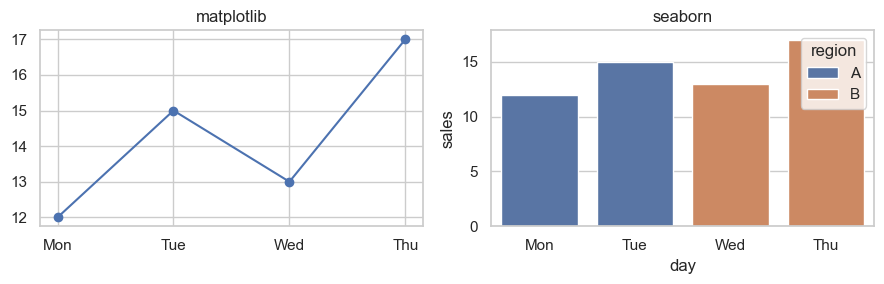

In [54]:
df = pd.DataFrame({'day': ['Mon', 'Tue', 'Wed', 'Thu'], 'sales': [12, 15, 13, 17], 'region': ['A', 'A', 'B', 'B']})
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(df['day'], df['sales'], marker='o')
axes[0].set_title('matplotlib')
sns.barplot(data=df, x='day', y='sales', hue='region', ax=axes[1])
axes[1].set_title('seaborn')
fig.tight_layout()
plt.show()
plt.close(fig)

## 7.3 pandas with Arrow and Parquet

Pandas is comfortable for interactive manipulation, while Arrow and Parquet are strong for interchange and typed storage. Combining them gives a practical notebook-to-storage workflow. The teaching point is to recognize storage as a separate concern from interactive tabular manipulation.


In [55]:
df = pd.DataFrame({'name': ['Alice', 'Bob'], 'score': [91, 84]})
path = GENERATED_DIR / 'workflow_scores.parquet'
pq.write_table(pa.Table.from_pandas(df), path)
loaded = pq.read_table(path).to_pandas()
print(path.exists())
print(loaded)

True
    name  score
0  Alice     91
1    Bob     84


## 7.4 Choosing the right package for the job

Choosing a package is an architectural decision, not just a stylistic one. Different steps in the same workflow may deserve different abstractions, and forcing one library to do everything often reduces clarity. A strong practitioner matches the package to the dominant structure of the task.


In [56]:
decision_frame = pd.DataFrame({
    'task': ['vectorized math', 'tabular cleaning', 'scientific routine', 'statistical plotting', 'parquet interchange'],
    'best_fit': ['numpy', 'pandas', 'scipy', 'seaborn', 'pyarrow'],
})
print(decision_frame)

                   task best_fit
0       vectorized math    numpy
1      tabular cleaning   pandas
2    scientific routine    scipy
3  statistical plotting  seaborn
4   parquet interchange  pyarrow


## 7.5 Common anti-patterns in early data work

Early data work often goes wrong through abstraction mismatches rather than syntax mistakes. Common anti-patterns include using pandas for everything, plotting before cleaning, and storing analytical data in the least structured format available. Recognizing these patterns early helps keep notebooks simpler and more reproducible.


In [57]:
anti_patterns = [
    'looping over dataframe rows for vectorizable work',
    'using screenshots instead of saving figures programmatically',
    'storing typed analytical tables only as ad hoc text',
]
print(anti_patterns)

['looping over dataframe rows for vectorizable work', 'using screenshots instead of saving figures programmatically', 'storing typed analytical tables only as ad hoc text']


### Common Mistake / Nuance

A common mistake is to judge libraries competitively rather than compositionally. In practice, the most effective workflows let each package handle the kind of structure it understands best. Cross-package fluency is therefore more about boundaries and conversions than about memorizing isolated APIs.


### Practice Prompts

- Build a tiny workflow that starts as a NumPy array, becomes a pandas dataframe, and ends in a saved Parquet file.
- Show how the same dataset supports one matplotlib chart and one seaborn chart for different communication goals.
- List three early-stage anti-patterns and explain what package choice would improve each one.


### Chapter Recap

The scientific stack is most effective when packages are combined intentionally. Arrays, tables, plotting, scientific routines, and interchange each have natural homes. The key skill is moving across those homes cleanly instead of overextending one abstraction.


# 8. Style, Performance, and Practical Judgment

Tool fluency is not enough by itself; experienced users also make good choices about performance, readability, and reproducibility. This final chapter turns package knowledge into engineering judgment. The goal is to help the learner see not just how to call the libraries, but how to write package-based notebook code that is maintainable and credible.


## 8.1 Vectorization vs Python loops

Vectorization is usually preferable for array-shaped numerical work because it moves computation into optimized library code. However, vectorization should serve clarity as well as speed. The real judgment is to prefer bulk operations when the problem is naturally bulk, not to write contorted code just to avoid every loop.


In [58]:
values = np.arange(1, 6)
loop_result = [value ** 2 for value in values]
vectorized_result = values ** 2
print(loop_result)
print(vectorized_result)

[np.int64(1), np.int64(4), np.int64(9), np.int64(16), np.int64(25)]
[ 1  4  9 16 25]


## 8.2 Memory awareness in tabular and array code

Performance is not only about execution time; memory layout and footprint matter too. Arrays, categories, and columnar storage all change how much memory a workflow consumes. A practical refresher should make memory visible enough that inefficient choices stop feeling invisible.


In [59]:
df = pd.DataFrame({'label': ['A', 'A', 'B', 'B', 'C'] * 100})
print(df.memory_usage(deep=True))
df['label'] = df['label'].astype('category')
print(df.memory_usage(deep=True))

Index      132
label    25000
dtype: int64
Index    132
label    758
dtype: int64


## 8.3 Readability vs clever chaining

Package ecosystems often enable highly compressed expressions, especially in pandas. Compact code can be elegant, but it can also become difficult to debug or explain. The important teaching point is that readable intermediate steps are often the stronger professional choice.


In [60]:
df = pd.DataFrame({'score': [80, 92, 76, 88], 'track': ['python', 'python', 'ml', 'ml']})
compact = df[df['score'] >= 80].groupby('track')['score'].mean()
step1 = df[df['score'] >= 80]
step2 = step1.groupby('track')['score'].mean()
print(compact)
print(step2)

track
ml        88.0
python    86.0
Name: score, dtype: float64
track
ml        88.0
python    86.0
Name: score, dtype: float64


## 8.4 Reproducibility and deterministic examples

Notebook examples should be deterministic enough to teach reliably. Seeds, explicit file paths, stable schemas, and controlled sample sizes all support reproducibility. This matters because educational material should fail rarely and explain itself clearly when it does fail.


In [61]:
rng = np.random.default_rng(123)
print(rng.integers(0, 10, size=5))
print((GENERATED_DIR / 'cities.parquet').exists())

[0 6 5 0 9]
True


## 8.5 How experienced Python users think about the scientific stack

Experienced users think in terms of problem structure before they think in terms of library loyalty. They choose arrays for dense numerics, dataframes for labeled tables, scientific routines for recognized computational patterns, and plotting tools for communication goals. The deepest lesson of this notebook is that package fluency is really structured judgment about representations, workflows, and tradeoffs.


In [62]:
principles = [
    'choose the abstraction that matches the data structure',
    'prefer reproducible file outputs over ad hoc manual steps',
    'optimize clarity before micro-optimizing syntax',
]
print(principles)

['choose the abstraction that matches the data structure', 'prefer reproducible file outputs over ad hoc manual steps', 'optimize clarity before micro-optimizing syntax']


### Common Mistake / Nuance

A common mistake is to treat package choice as a matter of habit rather than structure. Another is to optimize too early for speed while ignoring readability, reproducibility, or semantic fit. Strong scientific Python code usually looks calm, explicit, and well-matched to the shape of the problem.


### Practice Prompts

- Refactor one compact pandas chain into clearer staged code and explain the tradeoff.
- Show a reproducible plotting or storage example and identify the choices that made it reproducible.
- Summarize how you would decide among NumPy, pandas, SciPy, seaborn, matplotlib, and PyArrow for a new task.


### Chapter Recap

The final step in package fluency is judgment. Performance, readability, memory awareness, and reproducibility all shape whether notebook code is professionally useful. Experienced practitioners think first about structure and tradeoffs, and only then about specific API calls.
